# Import libraries

In [1]:
# Load core libraries for data handling, modeling, and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime

## Transaction Table

### Cleaning transaction table

In [2]:
# Load raw transaction data
dtypes = {
    'household_key': 'int64', 'BASKET_ID': 'int64', 'DAY': 'int16',
    'PRODUCT_ID': 'int32', 'QUANTITY': 'int32', 'SALES_VALUE': 'float32',
    'STORE_ID': 'int32', 'RETAIL_DISC': 'float32', 'TRANS_TIME': 'int16',
    'WEEK_NO': 'int16', 'COUPON_DISC': 'float32', 'COUPON_MATCH_DISC': 'float32',
}
df_trans = pd.read_csv('../datasets/transaction_data.csv', dtype=dtypes)

In [3]:
# Inspect schema and dtypes
df_trans.info()

<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int16  
 3   PRODUCT_ID         int32  
 4   QUANTITY           int32  
 5   SALES_VALUE        float32
 6   STORE_ID           int32  
 7   RETAIL_DISC        float32
 8   TRANS_TIME         int16  
 9   WEEK_NO            int16  
 10  COUPON_DISC        float32
 11  COUPON_MATCH_DISC  float32
dtypes: float32(4), int16(3), int32(3), int64(2)
memory usage: 123.8 MB


In [4]:
# Check for missing values
df_trans.isnull().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

In [5]:
# Check for duplicate rows
duplicate = df_trans.duplicated()
print(duplicate.sum())
df_trans[duplicate]

0


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC


In [6]:
# Summary statistics for numeric columns
df_trans.describe()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06
mean,1.271953e+03,3.402620e+10,3.887562e+02,2.891435e+06,1.004286e+02,3.104120e+00,3.142673e+03,-5.387054e-01,1.561586e+03,5.622150e+01,-1.641600e-02,-2.918564e-03
std,7.260660e+02,4.711649e+09,1.897210e+02,3.837404e+06,1.153436e+03,4.182274e+00,8.937113e+03,1.249191e+00,3.998378e+02,2.710223e+01,2.168410e-01,3.969004e-02
min,1.000000e+00,2.698485e+10,1.000000e+00,2.567100e+04,0.000000e+00,0.000000e+00,1.000000e+00,-1.800000e+02,0.000000e+00,1.000000e+00,-5.593000e+01,-7.700000e+00
25%,6.560000e+02,3.040805e+10,2.290000e+02,9.174590e+05,1.000000e+00,1.290000e+00,3.300000e+02,-6.900000e-01,1.308000e+03,3.300000e+01,0.000000e+00,0.000000e+00
50%,1.272000e+03,3.276081e+10,3.900000e+02,1.028816e+06,1.000000e+00,2.000000e+00,3.720000e+02,-1.000000e-02,1.613000e+03,5.600000e+01,0.000000e+00,0.000000e+00
75%,1.913000e+03,4.012685e+10,5.530000e+02,1.133018e+06,1.000000e+00,3.490000e+00,4.220000e+02,0.000000e+00,1.843000e+03,8.000000e+01,0.000000e+00,0.000000e+00
max,2.500000e+03,4.230536e+10,7.110000e+02,1.831630e+07,8.963800e+04,8.400000e+02,3.428000e+04,3.990000e+00,2.359000e+03,1.020000e+02,0.000000e+00,0.000000e+00


In [7]:
# Helper to plot a grid of histograms
def plot_histograms(data, columns,kde=True):
    plt.figure(figsize=(20,16))

    for i, col in enumerate(columns, 1):
        plt.subplot(4,3,i)
        sns.histplot(data=data,x=data[col],kde=kde)

    plt.tight_layout()

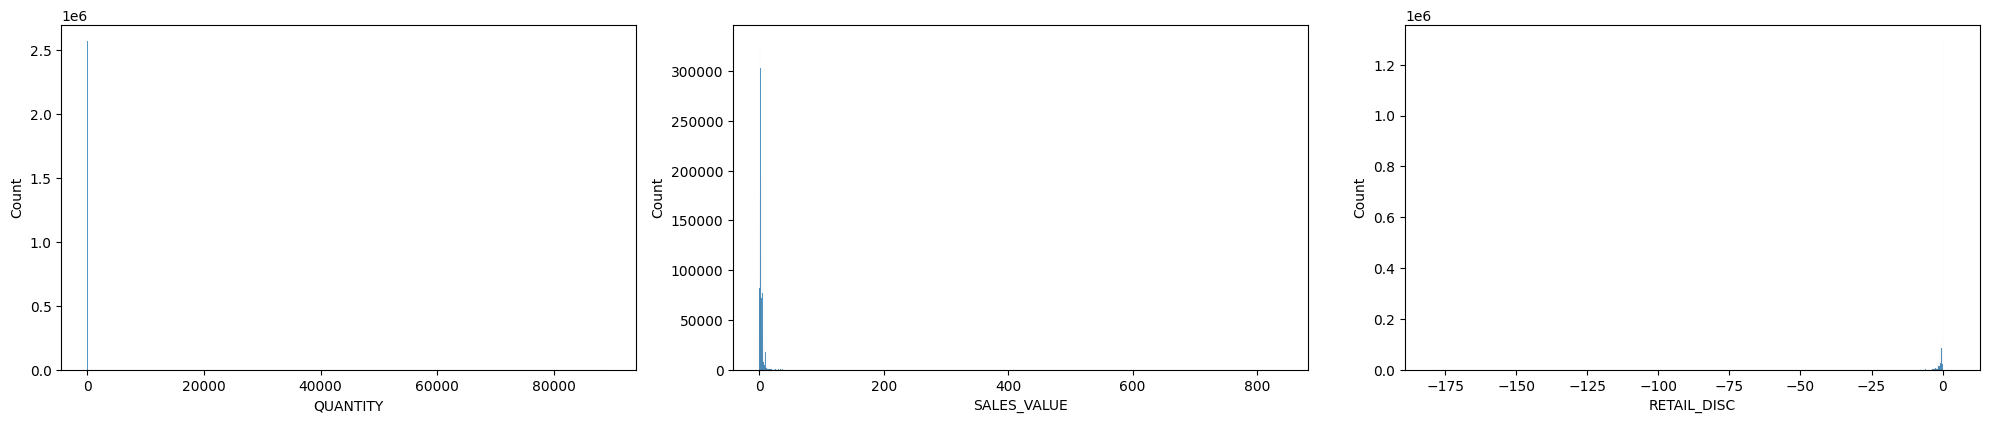

In [8]:
# Distribution of quantity, sales value, and discount
plot_histograms(data=df_trans, columns=["QUANTITY","SALES_VALUE",'RETAIL_DISC'],kde=False)

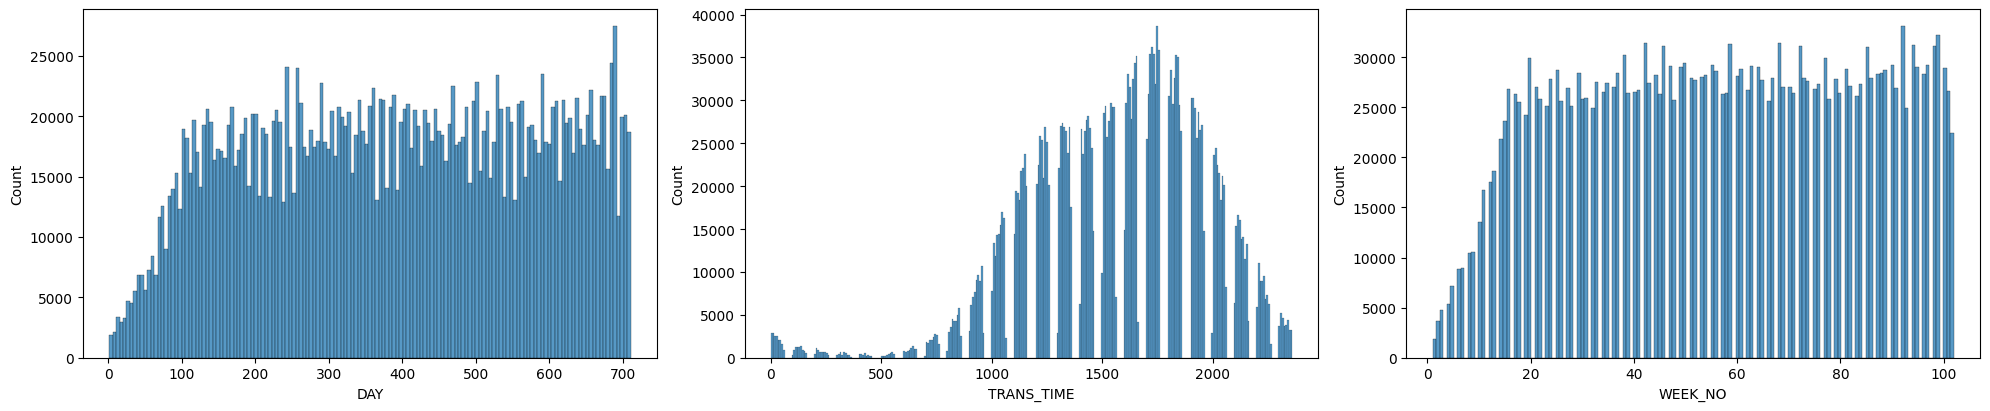

In [9]:
# Distribution of day, transaction time, and week number
plot_histograms(data=df_trans, columns=["DAY","TRANS_TIME","WEEK_NO"],kde=False)

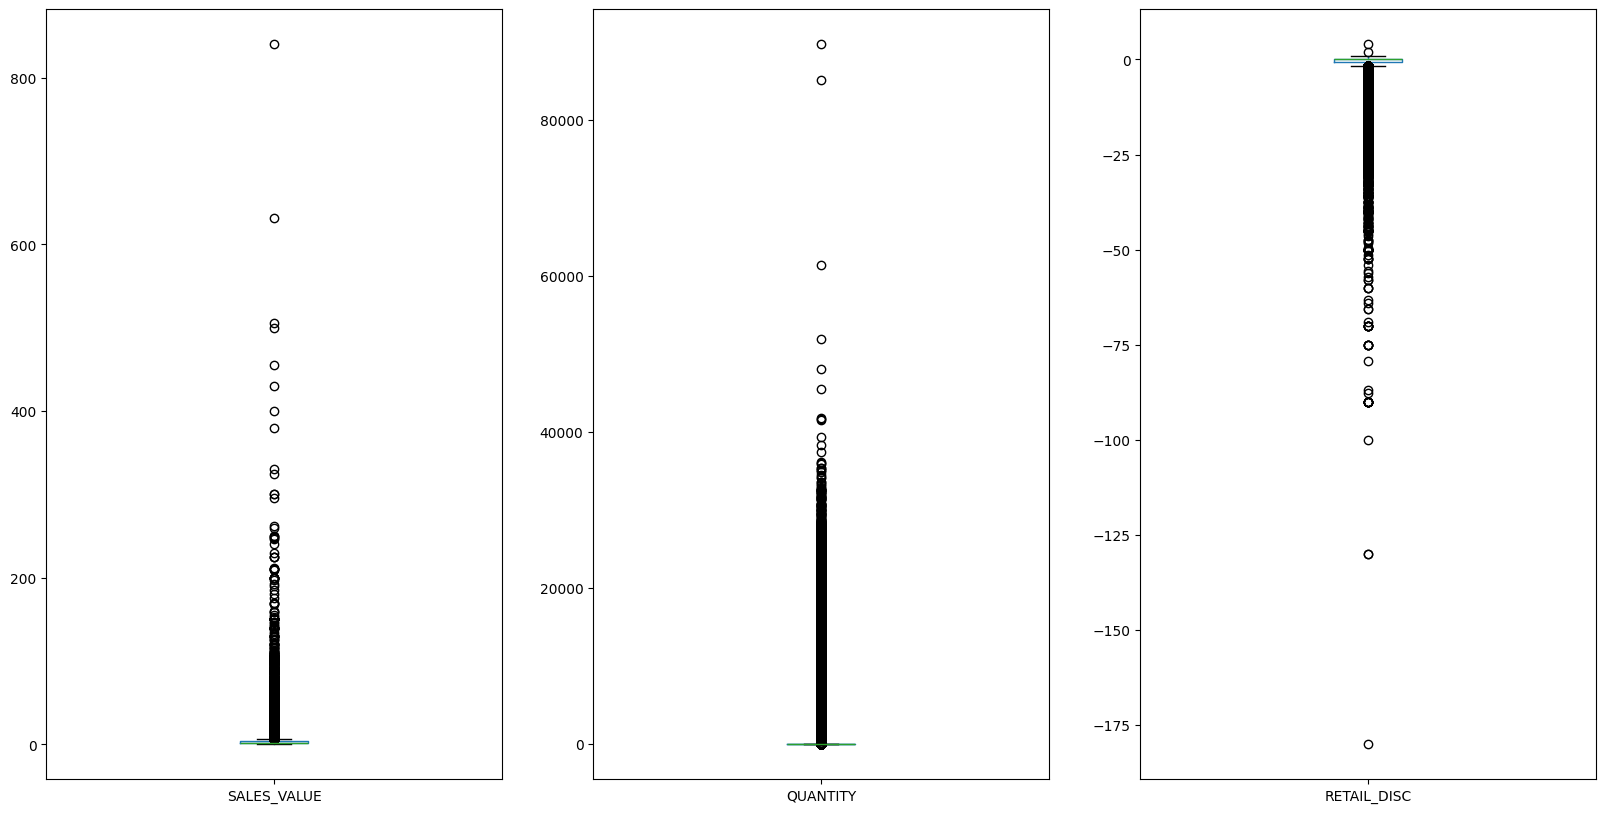

In [10]:
# Boxplots to visually flag outliers
for_cek = ['SALES_VALUE','QUANTITY','RETAIL_DISC']
fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(20,10))
for i,el in enumerate(for_cek):
    a = df_trans.boxplot(el, ax=axes.flatten()[i],grid=False)
plt.show()

In [11]:
# Top quantity values (outlier check)
potential_outlier_qty = sorted(df_trans["QUANTITY"], reverse=True)[:3]
potential_outlier_qty

[89638, 85055, 61335]

In [12]:
# Drop the extreme quantity outlier
df_trans = df_trans[df_trans['QUANTITY'] < 61335]

In [13]:
# Confirm max quantity after filtering
df_trans['QUANTITY'].max()

np.int32(51912)

In [14]:
# Drop zero-quantity rows
df_trans = df_trans[df_trans['QUANTITY'] != 0]

In [15]:
# Top sales value outliers
potential_outlier_sales = sorted(df_trans["SALES_VALUE"], reverse=True)[:2]
potential_outlier_sales

[840.0, 631.7999877929688]

In [16]:
# Drop the extreme sales value outliers
df_trans = df_trans[df_trans['SALES_VALUE'] < 631.8]

In [17]:
# Confirm max sales value after filtering
df_trans['SALES_VALUE'].max()

np.float32(505.0)

In [18]:
# Most negative discount values (outlier check)
potential_outlier_disc = sorted(df_trans["RETAIL_DISC"], reverse=False)[:4]
potential_outlier_disc

[-180.0, -130.02000427246094, -129.97999572753906, -100.0]

In [19]:
# Drop the extreme discount outlier
df_trans = df_trans[df_trans['RETAIL_DISC'] > -100.0]

In [20]:
# Confirm min discount after filtering
df_trans['RETAIL_DISC'].min()

np.float32(-90.05)

In [21]:
# Reset index after row removals
df_trans.reset_index(drop=True, inplace=True)

In [22]:
# Work on a copy going forward
new_df = df_trans.copy()

In [23]:
# Split DAY into calendar year (2017/2018)
new_df['YEAR'] = [2017 if x < 366 else 2018 for x in new_df['DAY']]

In [24]:
# Convert DAY into day-of-year within its year
new_df['DAY_NUM'] = new_df['DAY'].apply(lambda x: x - 365 if x > 365 else x)

In [25]:
# Cast day-of-year to string for date parsing
new_df['DAY_NUM'] = new_df['DAY_NUM'].astype(str)

In [26]:
# Cast year to string for date parsing
new_df['YEAR'] = new_df['YEAR'].astype(str)

In [27]:
# Pull out day-of-year series
day_num = new_df['DAY_NUM']

In [28]:
# Pull out year series
year = new_df['YEAR']

In [29]:
# Build a 'YYYY-DOY' date string
new_df['DATE'] = year + "-" + day_num

In [30]:
# Reference list of years in the data
year_list = ['2017', '2018']

In [31]:
# Parse the date string into an actual datetime
new_df['DATE'] = new_df['DATE'].apply(lambda x :datetime.strptime(x, "%Y-%j"))

In [32]:
# Derive day-of-week name
new_df['DAYS'] = new_df['DATE'].apply(lambda x: datetime.strftime(x, "%A"))

In [33]:
# Derive year-month label
new_df['MONTH'] = new_df['DATE'].apply(lambda x: datetime.strftime(x, "%Y-%m (%B)"))

In [34]:
# Convert TRANS_TIME (HHMM) to hour
new_df['TRANS_TIME'] = new_df['TRANS_TIME']/100

In [35]:
# Cast transaction hour to int
new_df['TRANS_TIME'] = new_df['TRANS_TIME'].astype(np.int64)

In [36]:
# Flag weekday vs weekend
new_df['DAY_CATEGORY'] = new_df['DATE'].dt.dayofweek

new_df['DAY_CATEGORY'] = ['weekday' if x < 5 else 'weekend' for x in new_df['DAY_CATEGORY']]

In [37]:
# Define Day (06:00-18:00) vs Night bucket
def condition(x):
    if x>=6 and x<=18:
        return "Day"
    else:
        return 'Night'

In [38]:
# Apply Day/Night category
new_df['TIME_CATEGORY'] = new_df['TRANS_TIME'].apply(condition)

In [39]:
# Define morning/afternoon/evening/night buckets
def conditions(x):
    if x>=4 and x<=9:
        return "morning"
    elif x>=10 and x<=15:
        return "afternoon"
    elif x>=16 and x<=21:
        return "evening"
    else:
        return 'night'

In [40]:
# Apply time-of-day category
new_df['TIMES_CATEGORY'] = new_df['TRANS_TIME'].apply(conditions)

In [41]:
# Preview the enriched transaction table
new_df

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,YEAR,DAY_NUM,DATE,DAYS,MONTH,DAY_CATEGORY,TIME_CATEGORY,TIMES_CATEGORY
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,16,1,0.0,0.0,2017,1,2017-01-01,Sunday,2017-01 (January),weekend,Day,evening
1,2375,26984851472,1,1033142,1,0.82,364,0.00,16,1,0.0,0.0,2017,1,2017-01-01,Sunday,2017-01 (January),weekend,Day,evening
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,16,1,0.0,0.0,2017,1,2017-01-01,Sunday,2017-01 (January),weekend,Day,evening
3,2375,26984851472,1,1082185,1,1.21,364,0.00,16,1,0.0,0.0,2017,1,2017-01-01,Sunday,2017-01 (January),weekend,Day,evening
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,16,1,0.0,0.0,2017,1,2017-01-01,Sunday,2017-01 (January),weekend,Day,evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2581252,1598,42305362535,711,92130,1,0.99,3228,0.00,15,102,0.0,0.0,2018,346,2018-12-12,Wednesday,2018-12 (December),weekday,Day,afternoon
2581253,1598,42305362535,711,114102,1,8.89,3228,0.00,15,102,0.0,0.0,2018,346,2018-12-12,Wednesday,2018-12 (December),weekday,Day,afternoon
2581254,1598,42305362535,711,133449,1,6.99,3228,0.00,15,102,0.0,0.0,2018,346,2018-12-12,Wednesday,2018-12 (December),weekday,Day,afternoon
2581255,1598,42305362535,711,6923644,1,4.50,3228,-0.49,15,102,0.0,0.0,2018,346,2018-12-12,Wednesday,2018-12 (December),weekday,Day,afternoon


## Adding product table

In [42]:
# Load product table
df_product = pd.read_csv('../datasets/product.csv')

In [43]:
# Inspect product table schema
df_product.info()

<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   PRODUCT_ID            92353 non-null  int64
 1   MANUFACTURER          92353 non-null  int64
 2   DEPARTMENT            92353 non-null  str  
 3   BRAND                 92353 non-null  str  
 4   COMMODITY_DESC        92353 non-null  str  
 5   SUB_COMMODITY_DESC    92353 non-null  str  
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  str  
dtypes: int64(2), str(5)
memory usage: 4.9 MB


In [44]:
# Check for missing values in product table
df_product.isnull().sum()

PRODUCT_ID              0
MANUFACTURER            0
DEPARTMENT              0
BRAND                   0
COMMODITY_DESC          0
SUB_COMMODITY_DESC      0
CURR_SIZE_OF_PRODUCT    0
dtype: int64

In [45]:
# Rows with blank department (data issue check)
liat = df_product[df_product['DEPARTMENT'] == ' ']
liat

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
52189,5126087,1,,National,,,
52190,5126088,1,,National,,,
52191,5126106,1,,National,,,
52192,5126107,1,,National,,,
55048,5977100,1,,National,,,
55054,5978648,1,,National,,,
55055,5978649,1,,National,,,
55056,5978650,1,,National,,,
55057,5978656,1,,National,,,
55058,5978657,1,,National,,,


In [46]:
# Drop rows with blank department
df_product = df_product[df_product['DEPARTMENT'] != " "]
df_product

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ
...,...,...,...,...,...,...,...
92348,18293142,6384,DRUG GM,National,BOOKSTORE,PAPERBACK BOOKS,
92349,18293439,6393,DRUG GM,National,BOOKSTORE,CHILDRENS LOW END,
92350,18293696,6406,DRUG GM,National,BOOKSTORE,PAPERBACK BEST SELLER,
92351,18294080,6442,DRUG GM,National,BOOKSTORE,PAPERBACK BOOKS,


In [47]:
# Merge transactions with product info
df = new_df.merge(df_product, how='left', left_on='PRODUCT_ID', right_on='PRODUCT_ID')
df

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,MONTH,DAY_CATEGORY,TIME_CATEGORY,TIMES_CATEGORY,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,16,1,...,2017-01 (January),weekend,Day,evening,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB
1,2375,26984851472,1,1033142,1,0.82,364,0.00,16,1,...,2017-01 (January),weekend,Day,evening,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,16,1,...,2017-01 (January),weekend,Day,evening,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,
3,2375,26984851472,1,1082185,1,1.21,364,0.00,16,1,...,2017-01 (January),weekend,Day,evening,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,16,1,...,2017-01 (January),weekend,Day,evening,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2581252,1598,42305362535,711,92130,1,0.99,3228,0.00,15,102,...,2018-12 (December),weekday,Day,afternoon,560,GROCERY,National,MARGARINES,MARGARINE: TUBS AND BOWLS,16 OZ
2581253,1598,42305362535,711,114102,1,8.89,3228,0.00,15,102,...,2018-12 (December),weekday,Day,afternoon,2398,GROCERY,National,BEERS/ALES,BEERALEMALT LIQUORS,12 OZ
2581254,1598,42305362535,711,133449,1,6.99,3228,0.00,15,102,...,2018-12 (December),weekday,Day,afternoon,2468,GROCERY,National,BEERS/ALES,BEERALEMALT LIQUORS,12 OZ
2581255,1598,42305362535,711,6923644,1,4.50,3228,-0.49,15,102,...,2018-12 (December),weekday,Day,afternoon,2390,GROCERY,National,BEERS/ALES,BEERALEMALT LIQUORS,4PK/10 OZ


In [48]:
# Confirm merged schema
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2581257 entries, 0 to 2581256
Data columns (total 26 columns):
 #   Column                Dtype         
---  ------                -----         
 0   household_key         int64         
 1   BASKET_ID             int64         
 2   DAY                   int16         
 3   PRODUCT_ID            int32         
 4   QUANTITY              int32         
 5   SALES_VALUE           float32       
 6   STORE_ID              int32         
 7   RETAIL_DISC           float32       
 8   TRANS_TIME            int64         
 9   WEEK_NO               int16         
 10  COUPON_DISC           float32       
 11  COUPON_MATCH_DISC     float32       
 12  YEAR                  str           
 13  DAY_NUM               str           
 14  DATE                  datetime64[us]
 15  DAYS                  str           
 16  MONTH                 str           
 17  DAY_CATEGORY          str           
 18  TIME_CATEGORY         str           
 19  TIMES_CATEG

## Adding Coupon and Campaign

In [49]:
# Load coupon-to-product/campaign mapping
coupon_desc = pd.read_csv('../datasets/coupon.csv')

In [50]:
# Load coupon redemption events
coupon_redempt = pd.read_csv('../datasets/coupon_redempt.csv')

In [51]:
# Link redemptions to their coupon/campaign details
coupon = coupon_redempt.merge(coupon_desc, how='left', left_on=['COUPON_UPC', 'CAMPAIGN'], right_on=['COUPON_UPC', 'CAMPAIGN'])
coupon

,household_key,DAY,COUPON_UPC,CAMPAIGN,PRODUCT_ID
0,1,421,10000085364,8,100512
1,1,421,10000085364,8,527731
2,1,421,10000085364,8,1054539
3,1,421,10000085364,8,802268
4,1,421,10000085364,8,846907
...,...,...,...,...,...
2198357,2500,624,55000013950,18,10118758
2198358,2500,624,55000013950,18,9676938
2198359,2500,624,55000013950,18,9676546
2198360,2500,624,55000013950,18,10118759


In [52]:
# Load campaign metadata (dates, description)
campaign_desc = pd.read_csv('../datasets/campaign_desc.csv')

In [53]:
# Attach campaign metadata to redemption records
coupons = coupon.merge(campaign_desc, how='left', left_on=['CAMPAIGN'], right_on=['CAMPAIGN'])
coupons

,household_key,DAY,COUPON_UPC,CAMPAIGN,PRODUCT_ID,DESCRIPTION,START_DAY,END_DAY
0,1,421,10000085364,8,100512,TypeA,412,460
1,1,421,10000085364,8,527731,TypeA,412,460
2,1,421,10000085364,8,1054539,TypeA,412,460
3,1,421,10000085364,8,802268,TypeA,412,460
4,1,421,10000085364,8,846907,TypeA,412,460
...,...,...,...,...,...,...,...,...
2198357,2500,624,55000013950,18,10118758,TypeA,587,642
2198358,2500,624,55000013950,18,9676938,TypeA,587,642
2198359,2500,624,55000013950,18,9676546,TypeA,587,642
2198360,2500,624,55000013950,18,10118759,TypeA,587,642


In [54]:
# Drop raw start/end day columns (not needed downstream)
coupons = coupons.drop(['START_DAY', 'END_DAY'], axis=1)

In [55]:
# Preview coupon+campaign table
coupons.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN,PRODUCT_ID,DESCRIPTION
0,1,421,10000085364,8,100512,TypeA
1,1,421,10000085364,8,527731,TypeA
2,1,421,10000085364,8,1054539,TypeA
3,1,421,10000085364,8,802268,TypeA
4,1,421,10000085364,8,846907,TypeA


In [56]:
# Attach campaign/coupon info to each transaction
df_final = df.merge(coupons, how='left', left_on=['household_key', 'DAY', 'PRODUCT_ID'], right_on=['household_key', 'DAY', 'PRODUCT_ID'])

In [57]:
# Fill non-campaign transactions with placeholder '-'
df_final['CAMPAIGN'] = df_final['CAMPAIGN'].fillna('-')
df_final['COUPON_UPC'] = df_final['COUPON_UPC'].fillna('-')
df_final['DESCRIPTION'] = df_final['DESCRIPTION'].fillna('-')

In [58]:
# Cast campaign id to string
df_final['CAMPAIGN'] = df_final['CAMPAIGN'].astype(str)
df_final['COUPON_UPC'] = df_final['COUPON_UPC'].astype(str)

In [59]:
# Confirm final merged schema
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 2581439 entries, 0 to 2581438
Data columns (total 29 columns):
 #   Column                Dtype         
---  ------                -----         
 0   household_key         int64         
 1   BASKET_ID             int64         
 2   DAY                   int16         
 3   PRODUCT_ID            int32         
 4   QUANTITY              int32         
 5   SALES_VALUE           float32       
 6   STORE_ID              int32         
 7   RETAIL_DISC           float32       
 8   TRANS_TIME            int64         
 9   WEEK_NO               int16         
 10  COUPON_DISC           float32       
 11  COUPON_MATCH_DISC     float32       
 12  YEAR                  str           
 13  DAY_NUM               str           
 14  DATE                  datetime64[us]
 15  DAYS                  str           
 16  MONTH                 str           
 17  DAY_CATEGORY          str           
 18  TIME_CATEGORY         str           
 19  TIMES_CATEG

In [60]:
# Check for duplicate rows after merges
duplicates = df_final.duplicated()
print(duplicates.sum())

86


In [61]:
# Drop duplicate rows
df_final = df_final.drop_duplicates()
df_final

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,TIMES_CATEGORY,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,COUPON_UPC,CAMPAIGN,DESCRIPTION
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,16,1,...,evening,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB,-,-,-
1,2375,26984851472,1,1033142,1,0.82,364,0.00,16,1,...,evening,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB,-,-,-
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,16,1,...,evening,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,,-,-,-
3,2375,26984851472,1,1082185,1,1.21,364,0.00,16,1,...,evening,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB,-,-,-
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,16,1,...,evening,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2581434,1598,42305362535,711,92130,1,0.99,3228,0.00,15,102,...,afternoon,560,GROCERY,National,MARGARINES,MARGARINE: TUBS AND BOWLS,16 OZ,-,-,-
2581435,1598,42305362535,711,114102,1,8.89,3228,0.00,15,102,...,afternoon,2398,GROCERY,National,BEERS/ALES,BEERALEMALT LIQUORS,12 OZ,-,-,-
2581436,1598,42305362535,711,133449,1,6.99,3228,0.00,15,102,...,afternoon,2468,GROCERY,National,BEERS/ALES,BEERALEMALT LIQUORS,12 OZ,-,-,-
2581437,1598,42305362535,711,6923644,1,4.50,3228,-0.49,15,102,...,afternoon,2390,GROCERY,National,BEERS/ALES,BEERALEMALT LIQUORS,4PK/10 OZ,-,-,-


In [62]:
# Free intermediate frames no longer needed, to reduce memory pressure
import gc
del df_trans, new_df, df, coupon, coupons
gc.collect()

521061

## Defining Store Which is Perform and Not

In [63]:
# Aggregate sales/customers/quantity per store
store = df_final.groupby('STORE_ID').agg({'household_key' : lambda x: x.nunique(),
                                       'SALES_VALUE' : 'sum', 'QUANTITY' : 'sum',
                                       'RETAIL_DISC' : 'sum'}).rename(columns={'household_key':'total_customer'}).sort_values(['SALES_VALUE', 'QUANTITY', 'RETAIL_DISC'], ascending=False)
store = store.reset_index()
store

,STORE_ID,total_customer,SALES_VALUE,QUANTITY,RETAIL_DISC
0,367,264,267625.218750,12743477,-33589.300781
1,406,134,216788.750000,16044216,-29704.880859
2,361,98,144698.843750,9012499,-21779.140625
3,429,99,142391.015625,16860489,-16975.599609
4,343,237,140471.750000,9582414,-22851.460938
...,...,...,...,...,...
577,2760,1,1.000000,2,-1.780000
578,639,1,0.850000,2,-0.180000
579,256,1,0.760000,1,0.000000
580,610,1,0.500000,1,-0.390000


In [64]:
# Cumulative % of total sales by store (Pareto)
store['cumpercent'] = (store['SALES_VALUE'].cumsum()/store['SALES_VALUE'].sum()*100).round(2)
store

,STORE_ID,total_customer,SALES_VALUE,QUANTITY,RETAIL_DISC,cumpercent
0,367,264,267625.218750,12743477,-33589.300781,3.32
1,406,134,216788.750000,16044216,-29704.880859,6.01
2,361,98,144698.843750,9012499,-21779.140625,7.81
3,429,99,142391.015625,16860489,-16975.599609,9.58
4,343,237,140471.750000,9582414,-22851.460938,11.32
...,...,...,...,...,...,...
577,2760,1,1.000000,2,-1.780000,100.00
578,639,1,0.850000,2,-0.180000,100.00
579,256,1,0.760000,1,0.000000,100.00
580,610,1,0.500000,1,-0.390000,100.00


In [65]:
# Performing stores: top ~80% of cumulative sales
store_perform = store[store['cumpercent'] < 81]
store_perform

,STORE_ID,total_customer,SALES_VALUE,QUANTITY,RETAIL_DISC,cumpercent
0,367,264,267625.218750,12743477,-33589.300781,3.320000
1,406,134,216788.750000,16044216,-29704.880859,6.010000
2,361,98,144698.843750,9012499,-21779.140625,7.810000
3,429,99,142391.015625,16860489,-16975.599609,9.580000
4,343,237,140471.750000,9582414,-22851.460938,11.320000
...,...,...,...,...,...,...
66,370,62,57139.917969,3035381,-11728.379883,77.690002
67,442,72,56885.371094,22921,-8980.719727,78.400002
68,404,91,55931.441406,1201603,-10011.559570,79.089996
69,445,175,55123.769531,27307,-10775.759766,79.769997


In [66]:
# Underperforming stores: remaining long tail
store_underperform = store[store['cumpercent'] > 81]
store_underperform

,STORE_ID,total_customer,SALES_VALUE,QUANTITY,RETAIL_DISC,cumpercent
71,306,72,52117.339844,24934,-13748.730469,81.080002
72,338,103,51468.441406,21247,-7048.000000,81.720001
73,448,111,50964.378906,20917,-7584.600098,82.349998
74,436,64,50734.839844,25636,-11876.259766,82.980003
75,289,118,50636.699219,25813,-10136.019531,83.610001
...,...,...,...,...,...,...
577,2760,1,1.000000,2,-1.780000,100.000000
578,639,1,0.850000,2,-0.180000,100.000000
579,256,1,0.760000,1,0.000000,100.000000
580,610,1,0.500000,1,-0.390000,100.000000


In [67]:
from matplotlib.ticker import PercentFormatter

<function matplotlib.pyplot.show(close=None, block=None)>

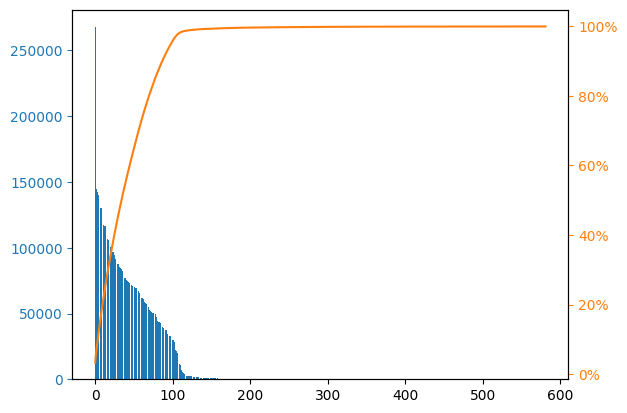

In [68]:
# Bar + cumulative-% overlay (Pareto chart)
fig, ax = plt.subplots()
ax.bar(store.index, store['SALES_VALUE'], color='C0')
ax2 = ax.twinx()
ax2.plot(store.index, store['cumpercent'], color='C1')
ax2.yaxis.set_major_formatter(PercentFormatter())

ax.tick_params(axis='y', colors='C0')
ax2.tick_params(axis='y', colors='C1')
plt.show

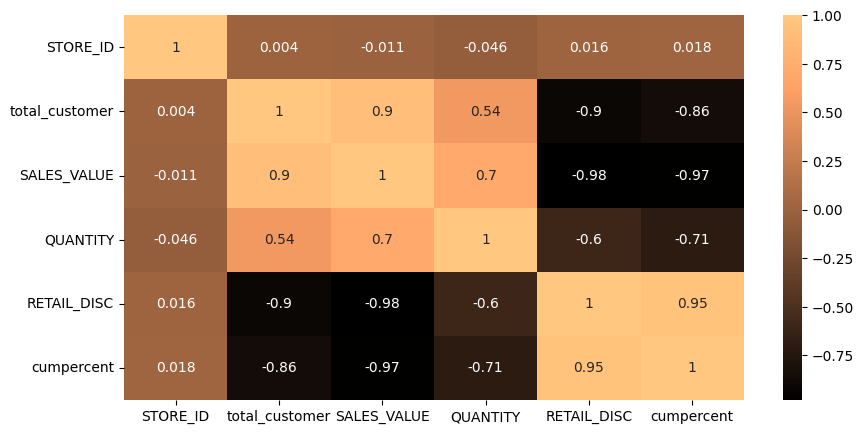

In [69]:
# Correlation heatmap across store-level metrics
plt.rcParams['figure.figsize'] = (10, 5)
sns.heatmap(store.corr(), cmap = 'copper', annot = True)

plt.show()

## The most traffic time of buying

In [70]:
# Customer traffic by weekday/weekend
week = df_final.groupby([df_final['DAY'], df_final['DAY_CATEGORY']]).agg({'household_key': lambda x: x.nunique()}).rename(columns={'household_key':'total_customer'}).sort_values(['total_customer'], ascending=False)
week

,,total_customer
DAY,DAY_CATEGORY,
246,weekend,521
610,weekend,507
641,weekday,489
692,weekday,487
284,weekday,479
...,...,...
5,weekday,23
1,weekend,13
2,weekday,12


In [71]:
# Total traffic share by weekday/weekend
weeks = week.groupby('DAY_CATEGORY').agg({'total_customer': 'sum'}).sort_values(['total_customer'], ascending=False)
weeks['percent_cust'] = weeks['total_customer'].apply(lambda x: (x / weeks['total_customer'].sum())*100).round(2)
weeks

,total_customer,percent_cust
DAY_CATEGORY,,
weekday,164278,72.9
weekend,61065,27.1


In [72]:
# Customer traffic by weekday/weekend x day/night
week_time = df_final.groupby([df_final['DAY'], df_final['DAY_CATEGORY'], df_final['TIME_CATEGORY']]).agg({'household_key': lambda x: x.nunique()}).rename(columns={'household_key':'total_customer'}).sort_values(['total_customer'], ascending=False)
week_time

,,,total_customer
DAY,DAY_CATEGORY,TIME_CATEGORY,
642,weekday,Day,409
684,weekday,Day,409
284,weekday,Day,406
277,weekday,Day,395
641,weekday,Day,385
...,...,...,...
2,weekday,Night,6
1,weekend,Night,4
5,weekday,Night,4


In [73]:
# Traffic share by weekday/weekend x day/night
week_times = week_time.groupby(['DAY_CATEGORY', 'TIME_CATEGORY']).agg({'total_customer': 'sum'}).sort_values(['total_customer'], ascending=False)
week_times['percent_cust'] = week_times['total_customer'].apply(lambda x: (x / week_times['total_customer'].sum())*100).round(2)
week_times = week_times.reset_index()
week_times

,DAY_CATEGORY,TIME_CATEGORY,total_customer,percent_cust
0,weekday,Day,126812,53.87
1,weekend,Day,46037,19.56
2,weekday,Night,44945,19.09
3,weekend,Night,17599,7.48


In [74]:
# Customer traffic by day of week
day = df_final.groupby([df_final['DAY'], df_final['DAYS']]).agg({'household_key': lambda x: x.nunique()}).rename(columns={'household_key':'total_customer'})
day

,,total_customer
DAY,DAYS,
1,Sunday,13
2,Monday,12
3,Tuesday,33
4,Wednesday,36
5,Thursday,23
...,...,...
707,Saturday,310
708,Sunday,315
709,Monday,317


In [75]:
# Traffic share by day of week
days = day.groupby(by='DAYS')['total_customer'].sum().reset_index(name='total_customer').sort_values(['total_customer'], ascending=False)
days['percent_cust'] = days['total_customer'].apply(lambda x: (x / week_times['total_customer'].sum())*100).round(2)
days

,DAYS,total_customer,percent_cust
4,Thursday,35326,15.01
6,Wednesday,35250,14.97
0,Friday,31881,13.54
5,Tuesday,31434,13.35
2,Saturday,30644,13.02
3,Sunday,30421,12.92
1,Monday,30387,12.91


In [76]:
# Customer traffic by time-of-day bucket
time = df_final.groupby([df_final['DAY'], df_final['TIMES_CATEGORY']]).agg({'household_key': lambda x: x.nunique()}).rename(columns={'household_key':'total_customer'}).sort_values(['total_customer'], ascending=False)
time

,,total_customer
DAY,TIMES_CATEGORY,
246,evening,299
277,afternoon,279
642,afternoon,270
692,evening,269
684,afternoon,260
...,...,...
9,night,1
643,night,1
278,evening,1


In [77]:
# Traffic share by time-of-day bucket
times = time.groupby('TIMES_CATEGORY').agg({'total_customer': 'sum'}).sort_values(['total_customer'], ascending=False)
times['percent_cust'] = times['total_customer'].apply(lambda x: (x / times['total_customer'].sum())*100).round(2)
times = times.reset_index()
times

,TIMES_CATEGORY,total_customer,percent_cust
0,evening,114009,47.06
1,afternoon,93864,38.75
2,morning,18906,7.80
3,night,15459,6.38


# Find an effective campaign

In [78]:
# Preview data before campaign analysis
df_final.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,TIMES_CATEGORY,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,COUPON_UPC,CAMPAIGN,DESCRIPTION
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,16,1,...,evening,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB,-,-,-
1,2375,26984851472,1,1033142,1,0.82,364,0.00,16,1,...,evening,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB,-,-,-
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,16,1,...,evening,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,,-,-,-
3,2375,26984851472,1,1082185,1,1.21,364,0.00,16,1,...,evening,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB,-,-,-
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,16,1,...,evening,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB,-,-,-


### Customer received campaign

In [79]:
# Count distinct products purchased per household
to_campaign_table = df_final.groupby('household_key').agg({'PRODUCT_ID':lambda x: x.nunique()}).rename(columns={'PRODUCT_ID':'total_product'})
to_campaign_table = to_campaign_table.reset_index()

In [80]:
# Load household-to-campaign assignment table
campaign_table = pd.read_csv('../datasets/campaign_table.csv')

In [81]:
# Join campaign assignments to household purchase activity
customer_received = campaign_table.merge(to_campaign_table, how='inner', left_on='household_key', right_on='household_key')
customer_received = customer_received.drop(['total_product'], axis=1)

In [82]:
# Count unique customers who received each campaign
customer_receiveds = customer_received.groupby(['CAMPAIGN', 'DESCRIPTION']).agg({'household_key':lambda x: x.nunique()}).rename(columns={'household_key':'total_customer_receive'})
customer_receiveds = customer_receiveds.reset_index()
customer_receiveds

,CAMPAIGN,DESCRIPTION,total_customer_receive
0,1,TypeB,13
1,2,TypeB,48
2,3,TypeC,12
3,4,TypeB,81
4,5,TypeB,166
5,6,TypeC,65
6,7,TypeB,198
7,8,TypeA,1076
8,9,TypeB,176
9,10,TypeB,123


### Distributed coupons and products

In [83]:
# Attach campaign dates to coupon info; compute campaign length
coupon_merge = coupon_desc.merge(campaign_desc, how='left', left_on='CAMPAIGN', right_on='CAMPAIGN')
coupon_merge['DAY_RUNNING'] = coupon_merge['END_DAY'] - coupon_merge['START_DAY']
coupon_merge = coupon_merge.drop(['START_DAY', 'END_DAY'], axis=1)

In [84]:
# Count coupons/products distributed per campaign
distributed_coupons = coupon_merge.groupby(['CAMPAIGN',
                                            'DESCRIPTION','DAY_RUNNING']).agg({'COUPON_UPC':lambda x: x.nunique(),
                                                                 'PRODUCT_ID':lambda x: x.nunique()}).rename(columns={'COUPON_UPC':'total_coupons','PRODUCT_ID':'total_product'})
distributed_coupons = distributed_coupons.reset_index()
distributed_coupons

,CAMPAIGN,DESCRIPTION,DAY_RUNNING,total_coupons,total_product
0,1,TypeB,37,11,383
1,2,TypeB,32,16,301
2,3,TypeC,56,34,506
3,4,TypeB,32,12,200
4,5,TypeB,34,11,443
5,6,TypeC,32,1,18
6,7,TypeB,34,8,259
7,8,TypeA,48,209,17178
8,9,TypeB,32,18,825
9,10,TypeB,32,14,393


### Distributed customers, coupons and products based on campaign

In [85]:
# Combine distribution and reach metrics per campaign
distributed_campaign = distributed_coupons.merge(customer_receiveds, how='left',
                                                 left_on=['CAMPAIGN','DESCRIPTION'],
                                                right_on=['CAMPAIGN','DESCRIPTION'])
distributed_campaign

,CAMPAIGN,DESCRIPTION,DAY_RUNNING,total_coupons,total_product,total_customer_receive
0,1,TypeB,37,11,383,13
1,2,TypeB,32,16,301,48
2,3,TypeC,56,34,506,12
3,4,TypeB,32,12,200,81
4,5,TypeB,34,11,443,166
5,6,TypeC,32,1,18,65
6,7,TypeB,34,8,259,198
7,8,TypeA,48,209,17178,1076
8,9,TypeB,32,18,825,176
9,10,TypeB,32,14,393,123


### Customer who redempt coupons

In [86]:
# Count customers/coupons/products actually redeemed per campaign
all_redempts = df_final.groupby(['CAMPAIGN','DESCRIPTION']).agg({'household_key':lambda x: x.nunique(),
                                                                  'COUPON_UPC':lambda x: x.nunique(),
                                                                  'PRODUCT_ID':lambda x: x.nunique()}).rename(columns={'household_key':'total_customers_redempt',
                                                                                                                       'COUPON_UPC':'total_coupons_redempt',
                                                                                                                       'PRODUCT_ID':'total_products_redempt'})
all_redempts = all_redempts.reset_index()
all_redempts = all_redempts[(all_redempts['CAMPAIGN'] != '-') & (all_redempts['DESCRIPTION'] != '-')]
all_redempts

,CAMPAIGN,DESCRIPTION,total_customers_redempt,total_coupons_redempt,total_products_redempt
1,1.0,TypeB,1,1,3
2,10.0,TypeB,6,6,10
3,11.0,TypeB,5,4,9
4,12.0,TypeB,11,9,15
5,13.0,TypeA,190,119,954
6,14.0,TypeC,17,10,38
7,15.0,TypeC,2,2,3
8,16.0,TypeB,13,10,32
9,17.0,TypeB,18,13,45
10,18.0,TypeA,209,113,1003


## Metrics Converted Rate (CR)

In [87]:
# Inspect distributed_campaign schema
distributed_campaign.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CAMPAIGN                30 non-null     int64
 1   DESCRIPTION             30 non-null     str  
 2   DAY_RUNNING             30 non-null     int64
 3   total_coupons           30 non-null     int64
 4   total_product           30 non-null     int64
 5   total_customer_receive  30 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.5 KB


In [88]:
# Inspect all_redempts schema
all_redempts.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 1 to 30
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   CAMPAIGN                 30 non-null     str  
 1   DESCRIPTION              30 non-null     str  
 2   total_customers_redempt  30 non-null     int64
 3   total_coupons_redempt    30 non-null     int64
 4   total_products_redempt   30 non-null     int32
dtypes: int32(1), int64(2), str(2)
memory usage: 1.2 KB


In [89]:
# Normalize CAMPAIGN id to match distributed_campaign's type
all_redempts['CAMPAIGN'] = all_redempts['CAMPAIGN'].str.replace('.0','',regex=False)
all_redempts['CAMPAIGN'] = all_redempts['CAMPAIGN'].astype(np.int64)

In [90]:
# Merge distribution and redemption metrics
campaign_converted_rate = distributed_campaign.merge(all_redempts, how='left',
                                              left_on=['CAMPAIGN','DESCRIPTION'],
                                             right_on=['CAMPAIGN','DESCRIPTION'])
campaign_converted_rate = campaign_converted_rate.fillna(0)

In [91]:
# Cast redemption counts to int
campaign_converted_rate['total_customers_redempt'] = campaign_converted_rate['total_customers_redempt'].astype(np.int64)
campaign_converted_rate['total_coupons_redempt'] = campaign_converted_rate['total_coupons_redempt'].astype(np.int64)
campaign_converted_rate['total_products_redempt'] = campaign_converted_rate['total_products_redempt'].astype(np.int64)

In [92]:
# Compute customer/coupon/product conversion rates
campaign_converted_rate['customers_converted'] = ((campaign_converted_rate['total_customers_redempt']/campaign_converted_rate['total_customer_receive'])*100).round(2)
campaign_converted_rate['coupons_converted'] = ((campaign_converted_rate['total_coupons_redempt']/campaign_converted_rate['total_coupons'])*100).round(2)
campaign_converted_rate['products_converted'] = ((campaign_converted_rate['total_products_redempt']/campaign_converted_rate['total_product'])*100).round(2)
campaign_converted_rate

,CAMPAIGN,DESCRIPTION,DAY_RUNNING,total_coupons,total_product,total_customer_receive,total_customers_redempt,total_coupons_redempt,total_products_redempt,customers_converted,coupons_converted,products_converted
0,1,TypeB,37,11,383,13,1,1,3,7.69,9.09,0.78
1,2,TypeB,32,16,301,48,2,4,7,4.17,25.00,2.33
2,3,TypeC,56,34,506,12,2,2,3,16.67,5.88,0.59
3,4,TypeB,32,12,200,81,5,5,8,6.17,41.67,4.00
4,5,TypeB,34,11,443,166,6,4,18,3.61,36.36,4.06
5,6,TypeC,32,1,18,65,1,1,2,1.54,100.00,11.11
6,7,TypeB,34,8,259,198,4,4,5,2.02,50.00,1.93
7,8,TypeA,48,209,17178,1076,149,95,495,13.85,45.45,2.88
8,9,TypeB,32,18,825,176,17,13,47,9.66,72.22,5.70
9,10,TypeB,32,14,393,123,6,6,10,4.88,42.86,2.54


## Metrics ROI

In [93]:
df_final.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,TIMES_CATEGORY,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,COUPON_UPC,CAMPAIGN,DESCRIPTION
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,16,1,...,evening,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB,-,-,-
1,2375,26984851472,1,1033142,1,0.82,364,0.00,16,1,...,evening,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB,-,-,-
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,16,1,...,evening,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,,-,-,-
3,2375,26984851472,1,1082185,1,1.21,364,0.00,16,1,...,evening,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB,-,-,-
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,16,1,...,evening,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB,-,-,-


In [94]:
# Copy final table for ROI calculation
ROI = df_final.copy()

In [95]:
# Keep only fields needed for ROI
ROI = ROI[['SALES_VALUE', 'RETAIL_DISC', 'CAMPAIGN', 'DESCRIPTION']]
ROI

,SALES_VALUE,RETAIL_DISC,CAMPAIGN,DESCRIPTION
0,1.39,-0.60,-,-
1,0.82,0.00,-,-
2,0.99,-0.30,-,-
3,1.21,0.00,-,-
4,1.50,-0.39,-,-
...,...,...,...,...
2581434,0.99,0.00,-,-
2581435,8.89,0.00,-,-
2581436,6.99,0.00,-,-
2581437,4.50,-0.49,-,-


In [96]:
# Clean discount field (strip sign, cast to float)
ROI['RETAIL_DISC'] = ROI['RETAIL_DISC'].astype(str)
ROI['RETAIL_DISC'] = ROI['RETAIL_DISC'].str.replace('-','',regex=False)
ROI['RETAIL_DISC'] = ROI['RETAIL_DISC'].astype(float)
ROI

,SALES_VALUE,RETAIL_DISC,CAMPAIGN,DESCRIPTION
0,1.39,0.60,-,-
1,0.82,0.00,-,-
2,0.99,0.30,-,-
3,1.21,0.00,-,-
4,1.50,0.39,-,-
...,...,...,...,...
2581434,0.99,0.00,-,-
2581435,8.89,0.00,-,-
2581436,6.99,0.00,-,-
2581437,4.50,0.49,-,-


In [97]:
# Inspect ROI working table schema
ROI.info()

<class 'pandas.DataFrame'>
Index: 2581353 entries, 0 to 2581438
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   SALES_VALUE  float32
 1   RETAIL_DISC  float64
 2   CAMPAIGN     str    
 3   DESCRIPTION  str    
dtypes: float32(1), float64(1), str(2)
memory usage: 88.6 MB


In [98]:
# Drop non-campaign transactions
ROI = ROI[ROI['CAMPAIGN'] != '-']

In [99]:
# Sum sales and discount per campaign
ROI1 = ROI.groupby(['CAMPAIGN','DESCRIPTION']).agg({'SALES_VALUE':'sum',
                                                        'RETAIL_DISC':'sum'}).rename(columns={'SALES_VALUE':'total_sales',
                                                                                             'RETAIL_DISC':'total_disc'})
ROI1 = ROI1.reset_index()
ROI1

,CAMPAIGN,DESCRIPTION,total_sales,total_disc
0,1.0,TypeB,8.000000,4.76
1,10.0,TypeB,76.070000,10.24
2,11.0,TypeB,21.840000,5.24
3,12.0,TypeB,50.939999,10.25
4,13.0,TypeA,4013.409912,1009.78
5,14.0,TypeC,93.220001,12.90
6,15.0,TypeC,7.370000,0.00
7,16.0,TypeB,128.199997,27.53
8,17.0,TypeB,139.720001,43.13
9,18.0,TypeA,5122.470215,1245.24


In [100]:
# Copy for ROI metric calculation
table_ROI = ROI1.copy()
table_ROI

,CAMPAIGN,DESCRIPTION,total_sales,total_disc
0,1.0,TypeB,8.000000,4.76
1,10.0,TypeB,76.070000,10.24
2,11.0,TypeB,21.840000,5.24
3,12.0,TypeB,50.939999,10.25
4,13.0,TypeA,4013.409912,1009.78
5,14.0,TypeC,93.220001,12.90
6,15.0,TypeC,7.370000,0.00
7,16.0,TypeB,128.199997,27.53
8,17.0,TypeB,139.720001,43.13
9,18.0,TypeA,5122.470215,1245.24


In [101]:
# Compute each campaign's share of sales and gross ROI
table_ROI['percent_sales'] = table_ROI['total_sales'].apply(lambda x: (x / table_ROI['total_sales'].sum())*100).round(2)
table_ROI['ROI'] = ((table_ROI['total_sales'] / table_ROI['total_disc'])*100).round(2)

In [102]:
# Inspect ROI table schema
table_ROI.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CAMPAIGN       30 non-null     str    
 1   DESCRIPTION    30 non-null     str    
 2   total_sales    30 non-null     float32
 3   total_disc     30 non-null     float64
 4   percent_sales  30 non-null     float32
 5   ROI            30 non-null     float64
dtypes: float32(2), float64(2), str(2)
memory usage: 1.3 KB


In [103]:
# Normalize CAMPAIGN id to int for merging
table_ROI['CAMPAIGN'] = table_ROI['CAMPAIGN'].str.replace('.0','',regex=False)
table_ROI['CAMPAIGN'] = table_ROI['CAMPAIGN'].astype(np.int64)
table_ROI

,CAMPAIGN,DESCRIPTION,total_sales,total_disc,percent_sales,ROI
0,1,TypeB,8.000000,4.76,0.060000,168.07
1,10,TypeB,76.070000,10.24,0.540000,742.87
2,11,TypeB,21.840000,5.24,0.160000,416.79
3,12,TypeB,50.939999,10.25,0.360000,496.98
4,13,TypeA,4013.409912,1009.78,28.520000,397.45
5,14,TypeC,93.220001,12.90,0.660000,722.64
6,15,TypeC,7.370000,0.00,0.050000,inf
7,16,TypeB,128.199997,27.53,0.910000,465.67
8,17,TypeB,139.720001,43.13,0.990000,323.95
9,18,TypeA,5122.470215,1245.24,36.400002,411.36


# Metrics to choose which effective campaign

In [104]:
# Combine conversion-rate and ROI metrics per campaign
metrics_campaign = campaign_converted_rate.merge(table_ROI, how='left',
                                              left_on=['CAMPAIGN','DESCRIPTION'],
                                             right_on=['CAMPAIGN','DESCRIPTION'])
metrics_campaign = metrics_campaign.fillna(0)
metrics_campaign

,CAMPAIGN,DESCRIPTION,DAY_RUNNING,total_coupons,total_product,total_customer_receive,total_customers_redempt,total_coupons_redempt,total_products_redempt,customers_converted,coupons_converted,products_converted,total_sales,total_disc,percent_sales,ROI
0,1,TypeB,37,11,383,13,1,1,3,7.69,9.09,0.78,8.000000,4.76,0.060000,168.07
1,2,TypeB,32,16,301,48,2,4,7,4.17,25.00,2.33,10.590000,5.44,0.080000,194.67
2,3,TypeC,56,34,506,12,2,2,3,16.67,5.88,0.59,9.210000,0.40,0.070000,2302.50
3,4,TypeB,32,12,200,81,5,5,8,6.17,41.67,4.00,30.170000,7.82,0.210000,385.81
4,5,TypeB,34,11,443,166,6,4,18,3.61,36.36,4.06,164.970001,30.70,1.170000,537.36
5,6,TypeC,32,1,18,65,1,1,2,1.54,100.00,11.11,4.580000,0.40,0.030000,1145.00
6,7,TypeB,34,8,259,198,4,4,5,2.02,50.00,1.93,28.779999,3.27,0.200000,880.12
7,8,TypeA,48,209,17178,1076,149,95,495,13.85,45.45,2.88,2314.659912,635.53,16.450001,364.21
8,9,TypeB,32,18,825,176,17,13,47,9.66,72.22,5.70,158.440002,53.02,1.130000,298.83
9,10,TypeB,32,14,393,123,6,6,10,4.88,42.86,2.54,76.070000,10.24,0.540000,742.87


# Clustering with RFM

In [105]:
# Export campaign metrics summary
metrics_campaign.to_excel('effective_campaign.xlsx')

In [106]:
# Copy transaction table for RFM inputs
for_RFM = df_final.copy()
for_RFM.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,TIMES_CATEGORY,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,COUPON_UPC,CAMPAIGN,DESCRIPTION
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,16,1,...,evening,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB,-,-,-
1,2375,26984851472,1,1033142,1,0.82,364,0.00,16,1,...,evening,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB,-,-,-
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,16,1,...,evening,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,,-,-,-
3,2375,26984851472,1,1082185,1,1.21,364,0.00,16,1,...,evening,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB,-,-,-
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,16,1,...,evening,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB,-,-,-


In [107]:
# Inspect RFM input schema
for_RFM.info()

<class 'pandas.DataFrame'>
Index: 2581353 entries, 0 to 2581438
Data columns (total 29 columns):
 #   Column                Dtype         
---  ------                -----         
 0   household_key         int64         
 1   BASKET_ID             int64         
 2   DAY                   int16         
 3   PRODUCT_ID            int32         
 4   QUANTITY              int32         
 5   SALES_VALUE           float32       
 6   STORE_ID              int32         
 7   RETAIL_DISC           float32       
 8   TRANS_TIME            int64         
 9   WEEK_NO               int16         
 10  COUPON_DISC           float32       
 11  COUPON_MATCH_DISC     float32       
 12  YEAR                  str           
 13  DAY_NUM               str           
 14  DATE                  datetime64[us]
 15  DAYS                  str           
 16  MONTH                 str           
 17  DAY_CATEGORY          str           
 18  TIME_CATEGORY         str           
 19  TIMES_CATEGORY  

In [108]:
# Recency: days since each household's last purchase
df_recency = for_RFM.groupby(by='household_key',
                        as_index=False)['DATE'].max()
df_recency.columns = ['household_key', 'LastPurchaseDate']
recent_date = df_recency['LastPurchaseDate'].max()
df_recency['Recency'] = df_recency['LastPurchaseDate'].apply(
    lambda x: (recent_date - x).days)
df_recency

,household_key,LastPurchaseDate,Recency
0,1,2018-12-07,5
1,2,2018-10-30,43
2,3,2018-12-04,8
3,4,2018-09-19,84
4,5,2018-12-04,8
...,...,...,...
2495,2496,2018-11-14,28
2496,2497,2018-12-01,11
2497,2498,2018-12-11,1
2498,2499,2018-12-10,2


In [109]:
# Frequency: distinct purchase dates per household
frequency_df = for_RFM.drop_duplicates().groupby(
    by=['household_key'], as_index=False)['DATE'].count()
frequency_df.columns = ['household_key', 'Frequency']
frequency_df

,household_key,Frequency
0,1,1710
1,2,713
2,3,921
3,4,300
4,5,222
...,...,...
2495,2496,1479
2496,2497,1958
2497,2498,859
2498,2499,1162


In [110]:
# Monetary: total spend per household
monetary_df = for_RFM.groupby(by='household_key', as_index=False)['SALES_VALUE'].sum()
monetary_df.columns = ['household_key', 'Monetary']
monetary_df

,household_key,Monetary
0,1,4330.160156
1,2,1954.339966
2,3,2653.209961
3,4,1200.109985
4,5,779.059998
...,...,...
2495,2496,4339.660156
2496,2497,7111.979980
2497,2498,2601.600098
2498,2499,3394.070068


In [111]:
# Combine R, F, M into one table
rf_df = df_recency.merge(frequency_df, on='household_key')
rfm_df = rf_df.merge(monetary_df, on='household_key').drop(
    columns='LastPurchaseDate')
rfm_df

,household_key,Recency,Frequency,Monetary
0,1,5,1710,4330.160156
1,2,43,713,1954.339966
2,3,8,921,2653.209961
3,4,84,300,1200.109985
4,5,8,222,779.059998
...,...,...,...,...
2495,2496,28,1479,4339.660156
2496,2497,11,1958,7111.979980
2497,2498,1,859,2601.600098
2498,2499,2,1162,3394.070068


In [112]:
# Bucket each metric into quartiles (R, F, M scores)
r_labels = range(4, 0, -1)
f_labels = range(1, 5)
m_labels = range(1,5)
r_groups = pd.qcut(rfm_df['Recency'], q=4, labels=r_labels)
f_groups = pd.qcut(rfm_df['Frequency'], q=4, labels=f_labels)
m_groups = pd.qcut(rfm_df['Monetary'], q=4, labels=m_labels)

In [113]:
# Attach quartile scores to the RFM table
rfm_df = rfm_df.assign(R = r_groups.values, F = f_groups.values, M = m_groups.values)
rfm_df

,household_key,Recency,Frequency,Monetary,R,F,M
0,1,5,1710,4330.160156,3,4,3
1,2,43,713,1954.339966,1,2,2
2,3,8,921,2653.209961,2,3,3
3,4,84,300,1200.109985,1,1,2
4,5,8,222,779.059998,2,1,1
...,...,...,...,...,...,...,...
2495,2496,28,1479,4339.660156,1,4,3
2496,2497,11,1958,7111.979980,2,4,4
2497,2498,1,859,2601.600098,4,3,3
2498,2499,2,1162,3394.070068,3,3,3


In [114]:
# Build a combined RFM score string per household
def join_rfm(x) :
    return str(x['R']) + str(x['F']) + str(x['M'])
rfm_df['score_concat'] = rfm_df.apply(join_rfm, axis=1)
rfm_df['score_concat'] = rfm_df['score_concat'].str.replace('.0','',regex=False)
rfm_df.head()

,household_key,Recency,Frequency,Monetary,R,F,M,score_concat
0,1,5,1710,4330.160156,3,4,3,343
1,2,43,713,1954.339966,1,2,2,122
2,3,8,921,2653.209961,2,3,3,233
3,4,84,300,1200.109985,1,1,2,112
4,5,8,222,779.059998,2,1,1,211


In [115]:
# Sum R+F+M into a single numeric score
rfm_df['rfm_score'] = rfm_df[['R','F','M']].sum(axis=1)
rfm_df.head()

,household_key,Recency,Frequency,Monetary,R,F,M,score_concat,rfm_score
0,1,5,1710,4330.160156,3,4,3,343,10
1,2,43,713,1954.339966,1,2,2,122,5
2,3,8,921,2653.209961,2,3,3,233,8
3,4,84,300,1200.109985,1,1,2,112,4
4,5,8,222,779.059998,2,1,1,211,4


In [116]:
# Map total RFM score to a named segment
def segmentation(x):
    if x['rfm_score'] >= 11:
        return 'Best Customers'
    elif (x['rfm_score'] >= 9) & (x['rfm_score'] <= 10):
        return 'Loyal'
    elif (x['rfm_score'] >= 7) & (x['rfm_score'] <= 8):
        return 'Promising'
    elif (x['rfm_score'] >= 5) & (x['rfm_score'] <= 6):
        return 'At Risk'
    else:
        return 'Lost Customers'

In [117]:
# Apply segment labels
rfm_df['segment_cust'] = rfm_df.apply(segmentation, axis=1)
rfm_df

,household_key,Recency,Frequency,Monetary,R,F,M,score_concat,rfm_score,segment_cust
0,1,5,1710,4330.160156,3,4,3,343,10,Loyal
1,2,43,713,1954.339966,1,2,2,122,5,At Risk
2,3,8,921,2653.209961,2,3,3,233,8,Promising
3,4,84,300,1200.109985,1,1,2,112,4,Lost Customers
4,5,8,222,779.059998,2,1,1,211,4,Lost Customers
...,...,...,...,...,...,...,...,...,...,...
2495,2496,28,1479,4339.660156,1,4,3,143,8,Promising
2496,2497,11,1958,7111.979980,2,4,4,244,10,Loyal
2497,2498,1,859,2601.600098,4,3,3,433,10,Loyal
2498,2499,2,1162,3394.070068,3,3,3,333,9,Loyal


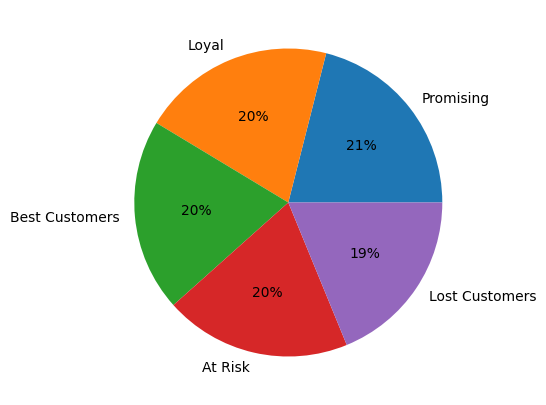

In [118]:
# Pie chart of customer segment distribution
plt.pie(rfm_df.segment_cust.value_counts(),
        labels=rfm_df.segment_cust.value_counts().index,
        autopct='%.0f%%')
plt.show()

In [119]:
# Average R/F/M and revenue share per segment
rfm_df_agg = rfm_df.groupby('segment_cust').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency':'avg_recency','Frequency':'avg_frequency','Monetary':'avg_monetary'}).round(1)
rfm_df_agg = rfm_df_agg.reset_index()
rfm_df_agg['percent_monetary'] = rfm_df_agg['avg_monetary'].apply(lambda x: (x / rfm_df_agg['avg_monetary'].sum())*100).round(2)
rfm_df_agg

,segment_cust,avg_recency,avg_frequency,avg_monetary,percent_monetary
0,At Risk,24.6,399.6,1206.300049,7.590000
1,Best Customers,1.7,2485.4,7984.799805,50.259998
2,Lost Customers,85.8,154.3,472.500000,2.970000
3,Loyal,6.5,1292.7,3973.399902,25.010000
4,Promising,14.0,758.0,2249.399902,14.160000


# Effective Customers and Campaign

In [120]:
# Attach RFM segment to every transaction
wrap_up = df_final.merge(rfm_df, how='left', on='household_key')
wrap_up

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,DESCRIPTION,Recency,Frequency,Monetary,R,F,M,score_concat,rfm_score,segment_cust
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,16,1,...,-,6,741,2842.889893,3,3,3,333,9,Loyal
1,2375,26984851472,1,1033142,1,0.82,364,0.00,16,1,...,-,6,741,2842.889893,3,3,3,333,9,Loyal
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,16,1,...,-,6,741,2842.889893,3,3,3,333,9,Loyal
3,2375,26984851472,1,1082185,1,1.21,364,0.00,16,1,...,-,6,741,2842.889893,3,3,3,333,9,Loyal
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,16,1,...,-,6,741,2842.889893,3,3,3,333,9,Loyal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2581348,1598,42305362535,711,92130,1,0.99,3228,0.00,15,102,...,-,0,3546,11516.830078,4,4,4,444,12,Best Customers
2581349,1598,42305362535,711,114102,1,8.89,3228,0.00,15,102,...,-,0,3546,11516.830078,4,4,4,444,12,Best Customers
2581350,1598,42305362535,711,133449,1,6.99,3228,0.00,15,102,...,-,0,3546,11516.830078,4,4,4,444,12,Best Customers
2581351,1598,42305362535,711,6923644,1,4.50,3228,-0.49,15,102,...,-,0,3546,11516.830078,4,4,4,444,12,Best Customers


In [121]:
# Count campaign redemptions by segment
customer_campaign = wrap_up.groupby(['segment_cust','CAMPAIGN','DESCRIPTION'])['CAMPAIGN'].count().reset_index(name='total_product_redempt')
customer_campaign = customer_campaign[customer_campaign['CAMPAIGN'] != '-']
customer_campaign['CAMPAIGN'] = customer_campaign['CAMPAIGN'].str.replace('.0','',regex=False)
customer_campaign['CAMPAIGN'] = customer_campaign['CAMPAIGN'].astype(np.int64)
customer_campaign

,segment_cust,CAMPAIGN,DESCRIPTION,total_product_redempt
1,At Risk,13,TypeA,13
2,At Risk,18,TypeA,48
3,At Risk,26,TypeA,3
4,At Risk,4,TypeB,1
5,At Risk,8,TypeA,19
...,...,...,...,...
68,Promising,4,TypeB,2
69,Promising,5,TypeB,8
70,Promising,7,TypeB,1
71,Promising,8,TypeA,67


In [122]:
# Filter to Best Customers' campaign activity
top_customers = wrap_up[['segment_cust','CAMPAIGN']]
top_customers = top_customers[(top_customers['segment_cust'] == 'Best Customers') & (top_customers['CAMPAIGN'] != '-')]
top_customers['CAMPAIGN'] = top_customers['CAMPAIGN'].str.replace('.0','',regex=False)
top_customers

,segment_cust,CAMPAIGN
626274,Best Customers,26
633839,Best Customers,26
637465,Best Customers,26
637468,Best Customers,26
637481,Best Customers,26
...,...,...
2549546,Best Customers,24
2549549,Best Customers,24
2549556,Best Customers,24
2549557,Best Customers,24


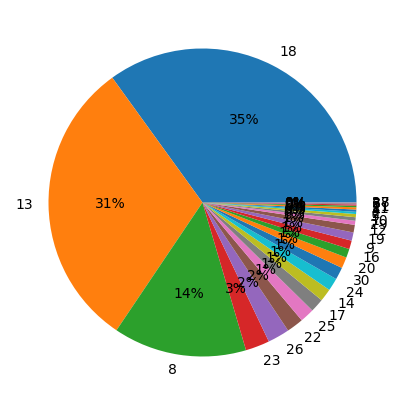

In [123]:
# Pie chart: Best Customers' campaign mix
plt.pie(top_customers.CAMPAIGN.value_counts(),
        labels=top_customers.CAMPAIGN.value_counts().index,
        autopct='%.0f%%')
plt.show()

In [124]:
# Filter to Loyal customers' campaign activity
high_value_customer = wrap_up[['segment_cust','CAMPAIGN']]
high_value_customer = high_value_customer[(high_value_customer['segment_cust'] == 'Loyal') & (high_value_customer['CAMPAIGN'] != '-')]
high_value_customer['CAMPAIGN'] = high_value_customer['CAMPAIGN'].str.replace('.0','',regex=False)
high_value_customer

,segment_cust,CAMPAIGN
643219,Loyal,26
643230,Loyal,26
666143,Loyal,26
678724,Loyal,26
678728,Loyal,26
...,...,...
2455238,Loyal,25
2455253,Loyal,25
2510181,Loyal,24
2527772,Loyal,24


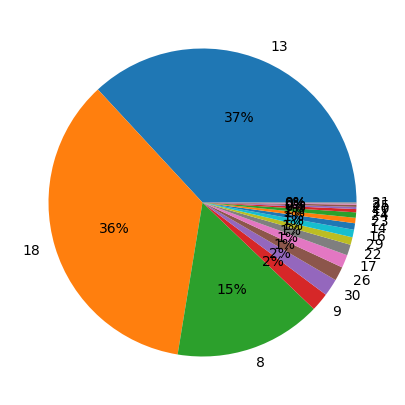

In [125]:
# Pie chart: Loyal customers' campaign mix
plt.pie(high_value_customer.CAMPAIGN.value_counts(),
        labels=high_value_customer.CAMPAIGN.value_counts().index,
        autopct='%.0f%%')
plt.show()

In [126]:
# Filter to Promising customers' campaign activity
promising_customer = wrap_up[['segment_cust','CAMPAIGN']]
promising_customer = promising_customer[(promising_customer['segment_cust'] == 'Promising') & (promising_customer['CAMPAIGN'] != '-')]
promising_customer['CAMPAIGN'] = promising_customer['CAMPAIGN'].str.replace('.0','',regex=False)
promising_customer

,segment_cust,CAMPAIGN
643041,Promising,26
688733,Promising,26
688735,Promising,26
688740,Promising,26
699972,Promising,26
...,...,...
2324872,Promising,23
2324873,Promising,23
2340482,Promising,22
2451581,Promising,25


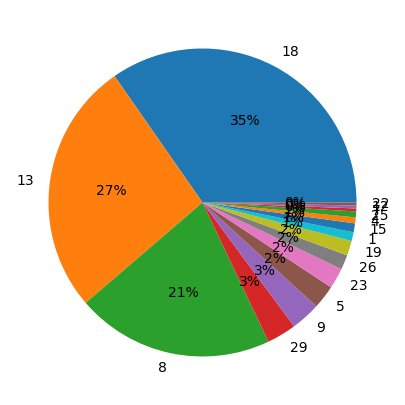

In [127]:
# Pie chart: Promising customers' campaign mix
plt.pie(promising_customer.CAMPAIGN.value_counts(),
        labels=promising_customer.CAMPAIGN.value_counts().index,
        autopct='%.0f%%')
plt.show()

In [128]:
# Filter to At Risk customers' campaign activity
atrisk_customer = wrap_up[['segment_cust','CAMPAIGN']]
atrisk_customer = atrisk_customer[(atrisk_customer['segment_cust'] == 'At Risk') & (atrisk_customer['CAMPAIGN'] != '-')]
atrisk_customer['CAMPAIGN'] = atrisk_customer['CAMPAIGN'].str.replace('.0','',regex=False)
atrisk_customer

,segment_cust,CAMPAIGN
705399,At Risk,26
705404,At Risk,26
705405,At Risk,26
1221443,At Risk,4
1414368,At Risk,8
...,...,...
2273651,At Risk,18
2273652,At Risk,18
2273653,At Risk,18
2273654,At Risk,18


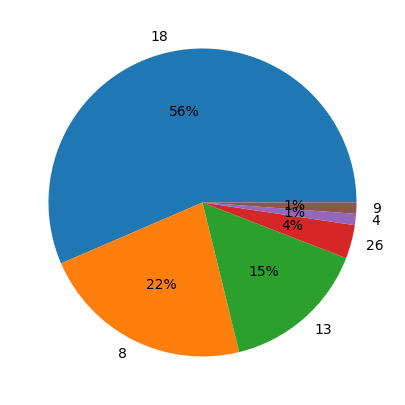

In [129]:
# Pie chart: At Risk customers' campaign mix
plt.pie(atrisk_customer.CAMPAIGN.value_counts(),
        labels=atrisk_customer.CAMPAIGN.value_counts().index,
        autopct='%.0f%%')
plt.show()

In [130]:
# Filter to Lost Customers with no campaign activity
lost_customer = wrap_up[['segment_cust','CAMPAIGN']]
lost_customer = lost_customer[(lost_customer['segment_cust'] == 'Lost Customers') & (lost_customer['CAMPAIGN'] == '-')]
lost_customer

,segment_cust,CAMPAIGN
21,Lost Customers,-
22,Lost Customers,-
23,Lost Customers,-
96,Lost Customers,-
121,Lost Customers,-
...,...,...
2555064,Lost Customers,-
2555065,Lost Customers,-
2555066,Lost Customers,-
2555067,Lost Customers,-


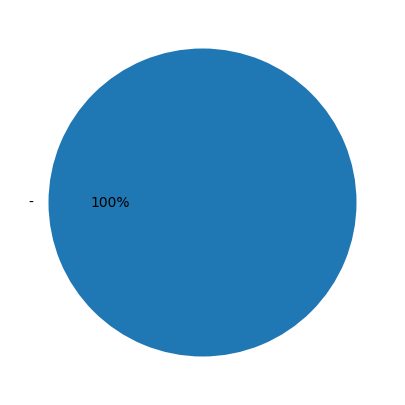

In [131]:
# Pie chart: Lost Customers' (lack of) campaign mix
plt.pie(lost_customer.CAMPAIGN.value_counts(),
        labels=lost_customer.CAMPAIGN.value_counts().index,
        autopct='%.0f%%')
plt.show()

# Compare Best Customers average growth sales when using and not using campaign 18

In [132]:
# Best Customers' non-campaign sales just before Campaign 18
top_cust_before_campaign = wrap_up[(wrap_up['CAMPAIGN'] == '-') & (wrap_up['segment_cust'] == 'Best Customers') & ((wrap_up['DAY'] <587) & (wrap_up['DAY'] >530))]

In [133]:
# Daily sales total for the pre-campaign window
bc_top_customer = top_cust_before_campaign.groupby('DATE')['SALES_VALUE'].sum()
bc_top_customer = pd.DataFrame(bc_top_customer)
bc_top_customer = bc_top_customer.reset_index()

In [134]:
# Day-over-day % change in sales
bc_top_customer['PCT_OTM'] = bc_top_customer['SALES_VALUE'].pct_change()
bc_top_customer['PCT_OTM'] = (bc_top_customer['PCT_OTM']*100).round(2)

In [135]:
# Average daily growth before Campaign 18
avg_growth_sales_before_campaign = bc_top_customer['PCT_OTM'].mean()
avg_growth_sales_before_campaign

np.float32(2.0132723)

In [136]:
# Best Customers' sales during the Campaign 18 window
top_cust_after_campaign = wrap_up[(wrap_up['segment_cust'] == 'Best Customers') & ((wrap_up['CAMPAIGN'] == '-') | (wrap_up['CAMPAIGN'] == '18.0')) & ((wrap_up['DAY'] >=587) & (wrap_up['DAY'] <=642))]

In [137]:
# Daily sales total for the campaign window
ac_top_customer = top_cust_after_campaign.groupby('DATE')['SALES_VALUE'].sum()
ac_top_customer = pd.DataFrame(ac_top_customer)
ac_top_customer = ac_top_customer.reset_index()

In [138]:
# Day-over-day % change in sales
ac_top_customer['PCT_OTM'] = ac_top_customer['SALES_VALUE'].pct_change()
ac_top_customer['PCT_OTM'] = (ac_top_customer['PCT_OTM']*100).round(2)

In [139]:
# Average daily growth during Campaign 18
avg_growth_sales_campaign = ac_top_customer['PCT_OTM'].mean()
avg_growth_sales_campaign

np.float32(3.6652727)

In [140]:
# Difference in average daily growth (after vs before)
diff_growth = avg_growth_sales_campaign - avg_growth_sales_before_campaign
diff_growth

np.float32(1.6520004)

In [141]:
# Overall % sales growth, before vs after Campaign 18
growth_sales = ((((ac_top_customer['SALES_VALUE'].sum())-(bc_top_customer['SALES_VALUE'].sum()))/(bc_top_customer['SALES_VALUE'].sum()))*100).round(2)
growth_sales

np.float32(10.8)

## Compare Best Customers avg growth sales when using and not using campaign 18 in the afternoon

In [142]:
# Same before-campaign window, restricted to afternoon
top_cust_before_campaigns = wrap_up[(wrap_up['CAMPAIGN'] == '-') & (wrap_up['segment_cust'] == 'Best Customers') & (wrap_up['TIMES_CATEGORY'] == 'afternoon') & ((wrap_up['DAY'] <587) & (wrap_up['DAY'] >530))]
top_cust_before_campaigns

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,DESCRIPTION,Recency,Frequency,Monetary,R,F,M,score_concat,rfm_score,segment_cust
1848593,568,35701111036,531,925514,2,0.66,366,-0.53,15,77,...,-,1,2884,8612.849609,4,4,4,444,12,Best Customers
1848594,568,35701111036,531,1124729,1,0.34,366,-0.26,15,77,...,-,1,2884,8612.849609,4,4,4,444,12,Best Customers
1848595,568,35701111036,531,7152455,1,5.88,366,0.00,15,77,...,-,1,2884,8612.849609,4,4,4,444,12,Best Customers
1848596,1453,35701115931,531,1005186,1,2.47,31862,0.00,13,77,...,-,1,6529,21661.289062,4,4,4,444,12,Best Customers
1848597,1453,35701115931,531,1138189,1,1.29,31862,0.00,13,77,...,-,1,6529,21661.289062,4,4,4,444,12,Best Customers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066457,2364,40535420436,586,15632175,1,1.69,673,0.00,11,84,...,-,5,2811,7414.100098,3,4,4,344,11,Best Customers
2069014,1479,40545416226,586,1053176,1,1.79,410,-0.20,14,84,...,-,2,3319,9129.229492,3,4,4,344,11,Best Customers
2069015,1479,40545416226,586,12696183,1,0.34,410,-0.25,14,84,...,-,2,3319,9129.229492,3,4,4,344,11,Best Customers
2069016,1479,40545416226,586,12731484,1,0.33,410,-0.26,14,84,...,-,2,3319,9129.229492,3,4,4,344,11,Best Customers


In [143]:
# Daily sales total, afternoon only
bc_top_customers = top_cust_before_campaigns.groupby('DATE')['SALES_VALUE'].sum()
bc_top_customers = pd.DataFrame(bc_top_customers)
bc_top_customers = bc_top_customers.reset_index()

In [144]:
# Day-over-day % change, afternoon only
bc_top_customers['PCT_OTM'] = bc_top_customers['SALES_VALUE'].pct_change()
bc_top_customers['PCT_OTM'] = (bc_top_customers['PCT_OTM']*100).round(2)

In [145]:
# Average daily growth before campaign, afternoon only
avg_growth_sales_before_campaigns = bc_top_customers['PCT_OTM'].mean()
avg_growth_sales_before_campaigns

np.float32(6.476)

In [146]:
# Same campaign window, restricted to afternoon
top_cust_after_campaigns = wrap_up[(wrap_up['segment_cust'] == 'Best Customers') & (wrap_up['TIMES_CATEGORY'] == 'afternoon') & ((wrap_up['CAMPAIGN'] == '-') | (wrap_up['CAMPAIGN'] == '18.0')) & ((wrap_up['DAY'] >=587) & (wrap_up['DAY'] <=642))]

In [147]:
# Daily sales total, afternoon only
ac_top_customers = top_cust_after_campaigns.groupby('DATE')['SALES_VALUE'].sum()
ac_top_customers = pd.DataFrame(ac_top_customers)
ac_top_customers = ac_top_customers.reset_index()

In [148]:
# Day-over-day % change, afternoon only
ac_top_customers['PCT_OTM'] = ac_top_customers['SALES_VALUE'].pct_change()
ac_top_customers['PCT_OTM'] = (ac_top_customers['PCT_OTM']*100).round(2)

In [149]:
# Average daily growth during campaign, afternoon only
avg_growth_sales_campaigns = ac_top_customers['PCT_OTM'].mean()
avg_growth_sales_campaigns

np.float32(9.244364)

In [150]:
# Difference in average daily growth, afternoon only
diff_growths = avg_growth_sales_campaigns - avg_growth_sales_before_campaigns
diff_growths

np.float32(2.768364)

In [151]:
# Overall % sales growth, before vs after, afternoon only
growth_sales2 = ((((ac_top_customers['SALES_VALUE'].sum())-(bc_top_customers['SALES_VALUE'].sum()))/(bc_top_customers['SALES_VALUE'].sum()))*100).round(2)
growth_sales2

np.float32(17.7)

## Growth sales in times category

In [152]:
# All segments' sales by time-of-day, before the campaign
growthsales_before_t = wrap_up[(wrap_up['CAMPAIGN'] == '-') & ((wrap_up['DAY'] <587) & (wrap_up['DAY'] >530))]
growthsales_before_t = growthsales_before_t.groupby(['segment_cust','DATE','TIMES_CATEGORY'])['SALES_VALUE'].sum()
growthsales_before_t = pd.DataFrame(growthsales_before_t)
growthsales_before_t = growthsales_before_t.reset_index()
growthsales_before_t

,segment_cust,DATE,TIMES_CATEGORY,SALES_VALUE
0,At Risk,2018-06-15,afternoon,318.139984
1,At Risk,2018-06-15,evening,276.630005
2,At Risk,2018-06-15,morning,91.220001
3,At Risk,2018-06-15,night,25.980000
4,At Risk,2018-06-16,afternoon,348.029999
...,...,...,...,...
1052,Promising,2018-08-08,night,143.949997
1053,Promising,2018-08-09,afternoon,1284.300049
1054,Promising,2018-08-09,evening,797.039978
1055,Promising,2018-08-09,morning,281.000000


In [153]:
# All segments' sales by time-of-day, during the campaign
growthsales_after_t = wrap_up[((wrap_up['CAMPAIGN'] == '-') | (wrap_up['CAMPAIGN'] == '18.0')) & ((wrap_up['DAY'] >586) & (wrap_up['DAY'] <643))]
growthsales_after_t = growthsales_after_t.groupby(['segment_cust','DATE','TIMES_CATEGORY'])['SALES_VALUE'].sum()
growthsales_after_t = pd.DataFrame(growthsales_after_t)
growthsales_after_t = growthsales_after_t.reset_index()
growthsales_after_t

,segment_cust,DATE,TIMES_CATEGORY,SALES_VALUE
0,At Risk,2018-08-10,afternoon,293.549988
1,At Risk,2018-08-10,evening,543.929993
2,At Risk,2018-08-10,morning,28.750000
3,At Risk,2018-08-11,afternoon,479.399994
4,At Risk,2018-08-11,evening,91.870003
...,...,...,...,...
1067,Promising,2018-10-03,night,106.419998
1068,Promising,2018-10-04,afternoon,1723.650024
1069,Promising,2018-10-04,evening,875.890015
1070,Promising,2018-10-04,morning,370.809998


## How demographic on Best Customers

In [154]:
# Load household demographic data
hh_demo = pd.read_csv('../datasets/hh_demographic.csv')

In [155]:
# Preview demographic table
hh_demo.head()

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,45-54,A,125-149K,Homeowner,2 Adults Kids,5+,3+,1609
1,45-54,U,175-199K,Homeowner,Single Male,1,None/Unknown,2322
2,45-54,A,125-149K,Homeowner,2 Adults Kids,3,1,1453
3,35-44,A,35-49K,Homeowner,2 Adults Kids,3,1,1430
4,45-54,A,25-34K,Homeowner,2 Adults Kids,5+,3+,718


## Best Customers Demo

In [156]:
# Filter to Best Customers segment
top_cust = wrap_up[wrap_up['segment_cust'] == 'Best Customers']

In [157]:
# Total spend/quantity per Best Customer household
top_custt = top_cust.groupby(['household_key','segment_cust']).agg({'SALES_VALUE':'sum','QUANTITY':'sum'})
top_custt = top_custt.reset_index()
top_custt

,household_key,segment_cust,SALES_VALUE,QUANTITY
0,6,Best Customers,5996.160156,94690
1,8,Best Customers,5534.970215,68333
2,13,Best Customers,13190.919922,1863829
3,18,Best Customers,7118.910156,260924
4,19,Best Customers,11299.610352,529311
...,...,...,...,...
501,2479,Best Customers,14279.700195,366135
502,2481,Best Customers,5403.500000,488227
503,2484,Best Customers,7824.640137,345374
504,2486,Best Customers,3265.520020,51632


In [158]:
# Join demographics; build a combined demographic profile string
top_cust_merge = hh_demo.merge(top_custt, how='inner', on='household_key')
top_cust_merge['concat'] = top_cust_merge['AGE_DESC'] + ', ' + top_cust_merge['MARITAL_STATUS_CODE'] + ', ' + top_cust_merge['INCOME_DESC'] + ', ' + top_cust_merge['HOMEOWNER_DESC'] + ', ' + top_cust_merge['HH_COMP_DESC'] + ', ' + top_cust_merge['HOUSEHOLD_SIZE_DESC'] + ', ' + top_cust_merge['KID_CATEGORY_DESC']

In [159]:
# Spend and quantity by demographic profile
top_cust_demo = top_cust_merge.groupby('concat').agg({'SALES_VALUE':'sum','QUANTITY':'sum'})
top_cust_demo = top_cust_demo.reset_index()
top_cust_demo

,concat,SALES_VALUE,QUANTITY
0,"19-24, A, 15-24K, Homeowner, 2 Adults No Kids,...",5159.399902,15883
1,"19-24, A, 35-49K, Renter, 2 Adults Kids, 3, 1",5822.640137,236900
2,"19-24, A, 35-49K, Renter, 2 Adults No Kids, 2,...",3630.620117,37546
3,"19-24, A, 50-74K, Homeowner, 2 Adults Kids, 3, 1",14420.900391,5978
4,"19-24, A, 75-99K, Unknown, 2 Adults Kids, 3, 1",6071.520020,102543
...,...,...,...
267,"65+, U, 35-49K, Homeowner, Single Female, 1, N...",4377.959961,36530
268,"65+, U, 50-74K, Homeowner, 2 Adults No Kids, 2...",8079.950195,678427
269,"65+, U, 50-74K, Homeowner, Single Male, 1, Non...",11200.799805,16916
270,"65+, U, Under 15K, Homeowner, 1 Adult Kids, 3, 2",11703.969727,7340


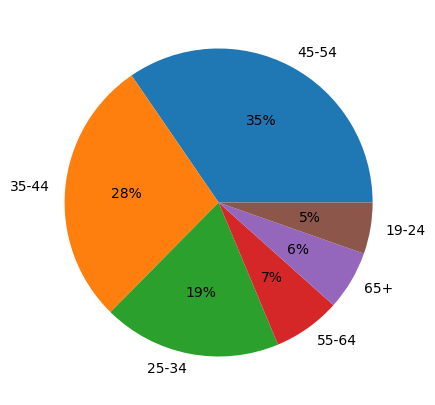

In [160]:
# Pie chart: Best Customers by age group
plt.pie(top_cust_merge.AGE_DESC.value_counts(),
        labels=top_cust_merge.AGE_DESC.value_counts().index,
        autopct='%.0f%%')
plt.show()

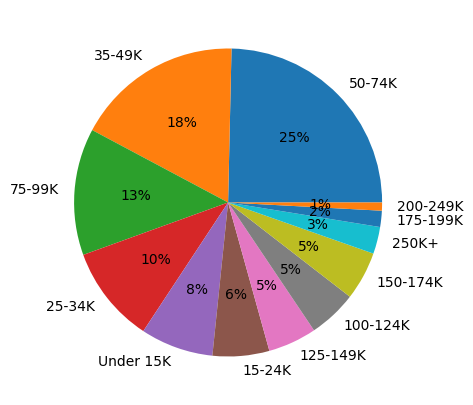

In [161]:
# Pie chart: Best Customers by income bracket
plt.pie(top_cust_merge.INCOME_DESC.value_counts(),
        labels=top_cust_merge.INCOME_DESC.value_counts().index,
        autopct='%.0f%%')
plt.show()

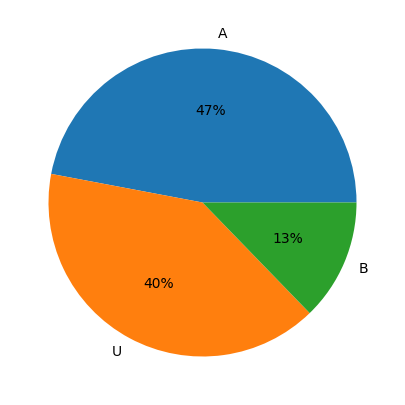

In [162]:
# Pie chart: Best Customers by marital status
plt.pie(top_cust_merge.MARITAL_STATUS_CODE.value_counts(),
        labels=top_cust_merge.MARITAL_STATUS_CODE.value_counts().index,
        autopct='%.0f%%')
plt.show()

## Forecasting

Pilot-store validation using LightGBM with Optuna-tuned hyperparameters.

In [163]:
# Imports and configuration: Campaign 18 window, pilot stores
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Campaign 18 window
CAMPAIGN_START = '2018-08-10'
CAMPAIGN_END   = '2018-10-04'

# Verified pilot stores
PILOT_STORES = [299, 317, 448]

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [164]:
def add_features(df):
    # Build calendar + lag/rolling-average features
    df = df.copy()
    df['dow'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    for lag in [7, 14]:
        df[f'lag_{lag}'] = df['SALES_VALUE'].shift(lag)
        df[f'ma_{lag}'] = df['SALES_VALUE'].rolling(lag, min_periods=1).mean()
    return df.dropna()

In [165]:
def forecast_iteratively(model, hist, dates, feature_cols):
    # Roll the model forward one day at a time, feeding each prediction
    # back in as history for the next day's lag/rolling features
    preds = []
    hist = hist.copy()
    for date in dates:
        # Register the date in history before computing its features
        if date not in hist.index:
            hist.loc[date, 'SALES_VALUE'] = np.nan
        hist = hist.sort_index()

        # Build the feature row for this date
        row = pd.DataFrame(index=[date])
        row['dow'] = date.dayofweek
        row['month'] = date.month
        row['is_weekend'] = int(date.dayofweek >= 5)
        for lag in [7, 14]:
            val = hist['SALES_VALUE'].shift(lag).loc[date]
            ma = hist['SALES_VALUE'].rolling(lag, min_periods=1).mean().shift(1).loc[date]
            row[f'lag_{lag}'] = val if pd.notna(val) else hist['SALES_VALUE'].mean()
            row[f'ma_{lag}'] = ma if pd.notna(ma) else hist['SALES_VALUE'].mean()

        # Predict and store this day's forecast
        pred = model.predict(row[feature_cols])[0]
        preds.append(pred)
        hist.loc[date, 'SALES_VALUE'] = pred
    return pd.Series(preds, index=dates)

In [166]:
def tune_and_forecast(df_final, store_id, n_trials=30):
    # Isolate one store's transactions and index by date
    store_df = df_final[df_final['STORE_ID'] == store_id].copy()
    store_df['DATE'] = pd.to_datetime(store_df['DATE'])
    store_df = store_df.set_index('DATE').sort_index()

    # Split into pre-campaign (training) and campaign-window (holdout) periods
    pre = store_df[:pd.Timestamp(CAMPAIGN_START) - pd.Timedelta(days=1)]
    post = store_df[CAMPAIGN_START:CAMPAIGN_END]
    pre_daily = pre.groupby('DATE')['SALES_VALUE'].sum().to_frame().astype('float64')
    post_daily = post.groupby('DATE')['SALES_VALUE'].sum().to_frame().astype('float64')

    # Build training features and train/validation split
    pre_feat = add_features(pre_daily)
    X = pre_feat.drop(columns=['SALES_VALUE'])
    y = pre_feat['SALES_VALUE']
    split = int(len(X) * 0.8)
    X_tr, X_val = X.iloc[:split], X.iloc[split:]
    y_tr, y_val = y.iloc[:split], y.iloc[split:]

    # Tune hyperparameters with Optuna
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'num_leaves': trial.suggest_int('num_leaves', 4, 31),
            'max_depth': trial.suggest_int('max_depth', 2, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 2, 15),
            'verbosity': -1,
            'random_state': 42,
        }
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_val)
        return np.sum(np.abs(y_val - pred)) / np.sum(y_val)

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    # Refit final model on full pre-campaign data with best params
    best_params = study.best_params
    best_params.update({'verbosity': -1, 'random_state': 42})
    model = lgb.LGBMRegressor(**best_params)
    model.fit(X, y)

    # Compute in-sample fit quality
    pred_pre = model.predict(X)
    wmape = np.sum(np.abs(y - pred_pre)) / np.sum(y) * 100
    mae = np.mean(np.abs(y - pred_pre))

    # Forecast the counterfactual (no-campaign) sales for the campaign window
    fcst = forecast_iteratively(model, pre_daily[['SALES_VALUE']], post_daily.index, X.columns)
    actual = post_daily['SALES_VALUE'].sum()
    forecast = fcst.sum()
    uplift = (actual - forecast) / forecast * 100

    return {
        'store_id': store_id, 'wmape': wmape, 'mae': mae,
        'actual': actual, 'forecast': forecast, 'uplift': uplift,
        'pre_daily': pre_daily, 'post_daily': post_daily, 'fcst': fcst,
    }

In [167]:
def run_pilot_validation(df_final, stores=PILOT_STORES, n_trials=30):
    # Run the forecast for each pilot store
    results = [tune_and_forecast(df_final, sid, n_trials) for sid in stores]

    # Print per-store metrics
    print(f"{'Store':<8}{'wMAPE':>8}{'MAE':>8}{'Actual':>12}{'Forecast':>12}{'Uplift':>9}")
    for r in results:
        print(f"{r['store_id']:<8}{r['wmape']:>7.1f}%{r['mae']:>8.1f}"
              f"{r['actual']:>12,.0f}{r['forecast']:>12,.0f}{r['uplift']:>8.1f}%")

    # Pool actual and counterfactual sales across stores, then compute uplift
    total_actual = sum(r['actual'] for r in results)
    total_forecast = sum(r['forecast'] for r in results)
    pooled_uplift = (total_actual - total_forecast) / total_forecast * 100

    print(f"\nPooled: actual=${total_actual:,.0f} forecast=${total_forecast:,.0f} "
          f"uplift={pooled_uplift:+.1f}%")

    return results, pooled_uplift


def plot_pilot_stores(results, out_path='pilot_stores_before_after.png'):
    # Plot actual vs. counterfactual sales, one panel per store
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=False)
    if len(results) == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        ax.plot(r['post_daily'].index, r['post_daily']['SALES_VALUE'],
                label='Actual (with Campaign 18)', marker='o', color='#39B2AB')
        ax.plot(r['fcst'].index, r['fcst'],
                label='Counterfactual (no campaign)', linestyle='--', marker='x', color='#21145F')
        ax.set_title(f"Store {r['store_id']}  (+{r['uplift']:.1f}%)")
        ax.set_ylabel('Daily Sales ($)')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

Store      wMAPE     MAE      Actual    Forecast   Uplift
299        52.9%    35.2       2,977       2,368    25.7%
317        53.1%    41.0       5,167       4,470    15.6%
448        44.8%    38.4       4,303       2,731    57.5%

Pooled: actual=$12,446 forecast=$9,569 uplift=+30.1%


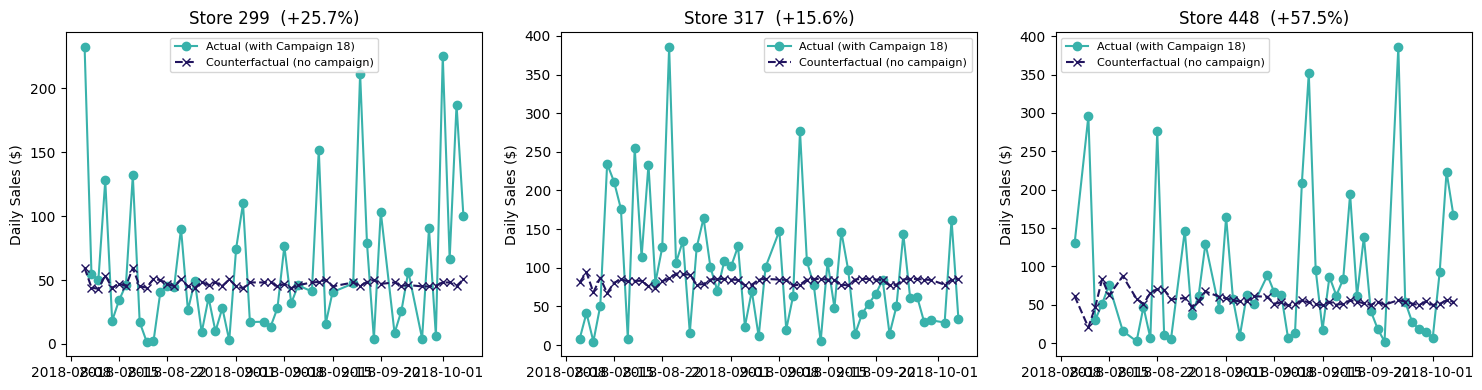

In [168]:
# Run pilot validation across all stores and plot actual vs. counterfactual sales
results, pooled_uplift = run_pilot_validation(df_final)
plot_pilot_stores(results)